# Crypto Market Sentiment and Bitcoin Price Behaviour: A Statistical Analysis

***

## 1. Problem Statement
> **About the data:** <br>
> This project combines two independent data sources: minute-level Bitcoin (BTC/USD) price data from Bitstamp exchange, and the daily Crypto Fear & Greed Index published by Alternative.me. The Fear & Greed Index is a composite sentiment indicator ranging from 0 (*Extreme Fear*) to 100 (*Extreme Greed*), computed daily from volatility, market momentum, social media activity, surveys, and Bitcoin dominance.

> **Research Problem:** <br>
> Cryptocurrency markets are known to be highly sentiment-driven. Yet it remains an open empirical question whether measurable differences in price behaviour — returns, volatility, and trading volume — can be attributed to the prevailing market sentiment regime. This project investigates that question statistically.

> **Objectives:**
>
> 1. Consolidate and clean two independent datasets from different sources into a single analytical frame. 
> 2. Compute financially meaningful daily metrics (log-returns, realised volatility, daily volume) from raw minute-level price data.
> 3. Perform EDA to understand distributions, temporal patterns, and relationships between sentiment and price metrics. 
> 4. Formally test whether key price metrics differ statistically across sentiment categories, using a rigorous, pre-registered statistical framework.
> 5. Quantify effect sizes to distinguish statistical significance from practical significance.

> **Research Questions:**
>
> 1. Does daily log-return differ significantly across Fear & Greed sentiment categories? 
> 2. Does realised volatility differ significantly across sentiment categories? 
> 3. Does trading volume differ significantly across sentiment categories? 
> 4. Are sentiment classification and the direction of daily price movement (up/down) statistically dependent?
> 5. How do log-returns and volatility correlate with the raw Fear & Greed Index value?

>**Significance Level:** <br>
$\alpha$ = 0.05, pre-registered before running any test to avoid *<u>p-hacking</u>* (*data dredging*). This means a <i><u>p-value</u></i> is required to be below this threshold for a result to be declared statistically significant. All tests run regardless of outcome.


***

## 2. Dataset Description
> **Source 1:** BTC/USD Minute Price Data
> * **Provider:** Bitstamp exchange, via [github.com/ff137/bitstamp-btcusd-minute-data](https://github.com/ff137/bitstamp-btcusd-minute-data)
> * **Format:** 1 CSV file; 6,846,600 rows x 6 columns (1-minute OHLCV candles)
> * **Period covered:** From 1 January 2012 to 7 January 2025


| Column | Type | Description |
| :---: | :---: | :---: |
| `timestamp` | unix int | POSIX timestamp (seconds since epoch) |
| `open` | float | Opening price in USD at the start of the minute |
| `high` | float | Highest price reached during the minute |
| `low` | float | Lowest price reached during the minute |
| `close` | float | Closing price at the end of the minute |
| `volume` | float | BTC volume traded during the minute | 


<br></br>
> **Source 2:** Crypto Fear & Greed Index
> * **Provider:** Alternative.me, via [api.alternative.me/fng/?limit=0&format=csv](https://api.alternative.me/fng/?limit=0&format=csv)
> * **Format:** 1 CSV fetched directly from the public API; one row per day; 3 columns
> * **Period covered:** From February 2018 to present (daily)


| Column | Type | Description |
| :---: | :---: | :---: |
| `timestamp` | date string | Date of the observation |
| `value` | int | Composite sentiment score |
| `value_classification` | categorical | Extreme Fear / Fear / Neutral / Greed / Extreme Greed | 


<br></br>
> **Data Consolidation Strategy:** <br>
> The two datasets are independent by construction - different sources, different granularities, different domains (price vs. sentiment). They are joined on date after the minute-level BTC data is aggregated to daily frequency. The effective analysis period is **February 2018 - January 2025** - the intersection between the BTC archive (January 2012 - January 2025) and the Fear & Greed Index (February 2018 - present).

> **Prior expectations before seeing the data:**
>
> * `fng_value` is expected to correlate positively with `log_return` - greedy market conditions are associated with buying pressure and upward price movement;
> * `volatility` is expected to be highest in *Extreme Fear* periods - panic selling tends to produce erratic intraday price swings in both directions;
> * `volume` is expected to be elevated at both sentiment extremes (*Extreme Fear* and *Extreme Greed*) - panic selling and FOMO buying both drive market participation, suggesting a U-shaped relationship rather than a monotonic one;
> * *Extreme Fear* days are expected to have a higher proportion of downward price movement, and *Extreme Greed* days - upward, making sentiment and price direction statistically dependent.


***

## 3. Imports and Setup

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from statsmodels.graphics.gofplots import qqplot
from scipy.stats import shapiro

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

ALPHA = 0.05

***

## 4. Load and Inspect Raw Data

**First inspection:** shape, null values, duplicates, data types and date range for each source independently. This step determines whether the datasets are structurally ready for use or require pre-cleaning before aggregation.

In [2]:
# Dataset 1: BTC/USD minute data
btc_raw = pd.read_csv('data/btcusd_bitstamp_1min_2012-2025.csv.gz', compression='gzip')
print('------ BTC Minute Data ------')
btc_raw.head()

------ BTC Minute Data ------


,timestamp,open,high,low,close,volume
0,1325412060,4.58,4.58,4.58,4.58,0.0
1,1325412120,4.58,4.58,4.58,4.58,0.0
2,1325412180,4.58,4.58,4.58,4.58,0.0
3,1325412240,4.58,4.58,4.58,4.58,0.0
4,1325412300,4.58,4.58,4.58,4.58,0.0


In [3]:
print(f'Shape: {btc_raw.shape}')
print(f'\nNull values:\n{btc_raw.isna().sum()}')
print(f'\nDuplicates: {btc_raw.duplicated().sum()}')

Shape: (6846600, 6)

Null values:
timestamp    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64

Duplicates: 0


In [4]:
btc_raw.info() # Description of the data (data type)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6846600 entries, 0 to 6846599
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   timestamp  int64  
 1   open       float64
 2   high       float64
 3   low        float64
 4   close      float64
 5   volume     float64
dtypes: float64(5), int64(1)
memory usage: 313.4 MB


In [5]:
btc_raw.describe().T # Description of the data (continuous data description)

,count,mean,std,min,25%,50%,75%,max
timestamp,6846600.0,1.530810e+09,1.185866e+08,1.325412e+09,1.428111e+09,1.530810e+09,1.633509e+09,1.736208e+09
open,6846600.0,1.562680e+04,2.136620e+04,3.800000e+00,4.172800e+02,6.397150e+03,2.575400e+04,1.082930e+05
high,6846600.0,1.563327e+04,2.137374e+04,3.800000e+00,4.174500e+02,6.398745e+03,2.575800e+04,1.083640e+05
low,6846600.0,1.562015e+04,2.135857e+04,3.800000e+00,4.171000e+02,6.395500e+03,2.575000e+04,1.082040e+05
close,6846600.0,1.562684e+04,2.136629e+04,3.800000e+00,4.172600e+02,6.397210e+03,2.575400e+04,1.082760e+05
volume,6846600.0,5.400153e+00,2.277095e+01,0.000000e+00,1.799021e-02,4.889694e-01,3.120345e+00,5.853852e+03


In [6]:
btc_raw['datetime_temp'] = pd.to_datetime(btc_raw['timestamp'], unit='s', utc=True)
print('BTC period:', btc_raw['datetime_temp'].dt.date.min(), '->', btc_raw['datetime_temp'].dt.date.max())

BTC period: 2012-01-01 -> 2025-01-07


In [7]:
# Dataset 2: Fear & Greed Index (fetched directly from Alternative.me API)
FNG_URL = 'https://api.alternative.me/fng/?limit=0&format=csv'
fng_raw = pd.read_csv(FNG_URL, skiprows=3)
print('------ Fear & Greed Index ------')
fng_raw.columns = ['timestamp', 'value', 'value_classification']
fng_raw.head(10)

------ Fear & Greed Index ------


,timestamp,value,value_classification
0,25-04-2026,31.0,Fear
1,24-04-2026,39.0,Fear
2,23-04-2026,46.0,Fear
3,22-04-2026,32.0,Fear
4,21-04-2026,33.0,Fear
5,20-04-2026,29.0,Fear
6,19-04-2026,27.0,Fear
7,18-04-2026,26.0,Fear
8,17-04-2026,21.0,Extreme Fear
9,16-04-2026,23.0,Extreme Fear


In [8]:
print(f'Shape: {fng_raw.shape}')
print(f'\nNull values:\n{fng_raw.isna().sum()}')
print(f'\nDuplicates: {fng_raw.duplicated().sum()}')

Shape: (3007, 3)

Null values:
timestamp               0
value                   5
value_classification    5
dtype: int64

Duplicates: 0


In [9]:
fng_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3007 entries, 0 to 3006
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             3007 non-null   object 
 1   value                 3002 non-null   float64
 2   value_classification  3002 non-null   object 
dtypes: float64(1), object(2)
memory usage: 70.6+ KB


In [10]:
fng_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
value,3002.0,46.087275,22.064181,5.0,27.0,45.0,65.0,95.0


In [11]:
fng_clean = fng_raw[fng_raw['timestamp'].str.match(r'\d{2}-\d{2}-\d{4}')]
print('FNG period:', fng_clean['timestamp'].iloc[-1], '->', fng_clean['timestamp'].iloc[0])

FNG period: 01-02-2018 -> 25-04-2026


>**Initial observations:**
> * BTC data: 6,846,600 rows, 6 columns - no null values, no duplicates. Structurally clean.
>    * The `timestamp` column is stored as int64 (Unix/POSIX timestamp) and must be converted to datetime before aggregation. <br><br>
> * Fear & Greed data: one row per day; 3007 rows, 3 columns - the dataset contains a small number of missing values (5 observations) in the `value` and `value_classification` columns.
>    * The `value` column is therefore stored as float and should be cast to integer after handling the missing data;
>    * The `timestamp` column is an object (date string) and must be parsed to datetime;
>    * The sentiment categories in `value_classification` are: *Extreme Fear*, *Fear*, *Neutral*, *Greed*, *Extreme Greed* - five ordered groups that will serve as the primary grouping variable throughout hypothesis testing. <br><br>
> * BTC prices cover 1 January 2012 - 7 January 2025; the Fear & Greed Index covers 1 February 2018 - present, resulting in approximately 6 years and 11 months of overlapping data.


***

## 5. Data Preprocessing & Consolidation
>**Why this step matters for subsequent analysis?** <br>
>The two raw datasets are at incompatible granularities: BTC data is per-minute, while Fear & Greed is reported daily. Before any join is possible, the BTC data must be aggregated to daily frequency. During aggregation, three financially meaningful metrics are computed:
>
> * **Daily log-return** - the continuously-compounded return from the day's opening to closing price. Log-returns are preferred over simple returns in financial analysis because they are time-additive and exhibit more desirable statistical properties;
> * **Realised volatility** - the standard deviation of all within-day minute-level log-returns, capturing intraday price fluctuations independently of direction;
> * **Daily volume** - the sum of BTC trading volume across all minutes in the day, reflecting overall market activity; <br><br>
> * In addition, the Fear & Greed dataset contains 5 observations with missing values in the `value` and `value_classification` columns. These are removed prior to merging, as they represent less than 0.2% of the data and their exclusion does not materially affect the analysis.
>
>The date column from each dataset is then used as the merge key.

In [12]:
# Step 1: Parse BTC timestamps and compute minute-level log-returns
btc_raw['datetime'] = pd.to_datetime(btc_raw['timestamp'], unit='s', utc=True)
btc_raw['date'] = btc_raw['datetime'].dt.date

# Minute log-return: ln(close_t / open_t) for each 1-min candle
# Using open-to-close within each minute avoids look-ahead bias
btc_raw['minute_log_ret'] = np.log(btc_raw['close'] / btc_raw['open'])

btc_raw[['datetime', 'date', 'open', 'close', 'minute_log_ret', 'volume']].head()

,datetime,date,open,close,minute_log_ret,volume
0,2012-01-01 10:01:00+00:00,2012-01-01,4.58,4.58,0.0,0.0
1,2012-01-01 10:02:00+00:00,2012-01-01,4.58,4.58,0.0,0.0
2,2012-01-01 10:03:00+00:00,2012-01-01,4.58,4.58,0.0,0.0
3,2012-01-01 10:04:00+00:00,2012-01-01,4.58,4.58,0.0,0.0
4,2012-01-01 10:05:00+00:00,2012-01-01,4.58,4.58,0.0,0.0


-> The BTC `timestamp` column was successfully converted to datetime format, and minute-level log-returns were computed for each observation.

In [13]:
# Step 2: Aggregate to daily frequency
# For each day:
#   - daily_open = first open price of the day (first minute)
#   - daily_close = last close price of the day (last minute)
#   - log_return = ln(daily_close / daily_open) - daily directional return
#   - volatility = std of all minute log-returns within the day (realised volatility)
#   - volume = total BTC traded during the day

daily_agg = btc_raw.groupby('date').agg( daily_open = ('open', 'first'),   
                                         daily_close = ('close', 'last'),
                                         volatility = ('minute_log_ret', 'std'),   # Realised intraday volatility
                                         volume = ('volume', 'sum')).reset_index()

daily_agg['log_return'] = np.log(daily_agg['daily_close'] / daily_agg['daily_open'])
daily_agg['direction'] = daily_agg['log_return'].apply(lambda x: 'Up' if x >= 0 else 'Down')
daily_agg['date'] = pd.to_datetime(daily_agg['date'])

print(f'Daily BTC data: {daily_agg.shape}')
daily_agg.head()

Daily BTC data: (4756, 7)


,date,daily_open,daily_close,volatility,volume,log_return,direction
0,2012-01-01,4.58,4.84,0.000000,10.000000,0.055216,Up
1,2012-01-02,4.84,5.00,0.000000,10.100000,0.032523,Up
2,2012-01-03,5.00,5.29,0.000000,107.085281,0.056380,Up
3,2012-01-04,5.29,5.57,0.000965,107.233260,0.051577,Up
4,2012-01-05,5.57,6.42,0.000263,70.328742,0.142023,Up


-> The minute-level BTC data was aggregated to daily frequency, generating key financial metrics including daily open and close prices, realised volatility, total trading volume, log-returns, and a directional indicator (Up/Down), preparing the dataset for merging with the Fear & Greed Index.

In [14]:
# Step 3: Parse Fear & Greed dates and cast types
fng = fng_raw.copy()
fng.columns = fng.columns.str.strip()  # Strip any whitespace from column names

fng['date'] = pd.to_datetime(fng['timestamp'], dayfirst=True, errors='coerce')
fng['value'] = pd.to_numeric(fng['value'], errors='coerce')
print(f'Rows before dropping missing values: {len(fng)}')
print(f'Missing values:\n{fng[["date", "value", "value_classification"]].isna().sum()}')
print()

fng = fng.dropna(subset=['date', 'value'])
fng['value'] = fng['value'].astype(int)  # Safe to cast now - no NaN values remain
print(f'Rows after dropping missing values: {len(fng)} ({len(fng_raw) - len(fng)} rows removed)')
print(f'Missing values:\n{fng[["date", "value", "value_classification"]].isna().sum()}')

fng = fng[['date', 'value', 'value_classification']]\
         .rename(columns={'value': 'fng_value', 'value_classification': 'sentiment'})

# Enforce the natural ordering of categories (Extreme Fear -> Extreme Greed)
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
fng['sentiment'] = pd.Categorical(fng['sentiment'], categories=sentiment_order, ordered=True)

print(f'Fear & Greed data: {fng.shape}')
print(f'\nSentiment category counts:\n{fng["sentiment"].value_counts().sort_index()}')
print()
fng.head()

Rows before dropping missing values: 3007
Missing values:
date                    5
value                   5
value_classification    5
dtype: int64

Rows after dropping missing values: 3002 (5 rows removed)
Missing values:
date                    0
value                   0
value_classification    0
dtype: int64
Fear & Greed data: (3002, 3)

Sentiment category counts:
sentiment
Extreme Fear     687
Fear             852
Neutral          392
Greed            790
Extreme Greed    281
Name: count, dtype: int64



,date,fng_value,sentiment
0,2026-04-25,31,Fear
1,2026-04-24,39,Fear
2,2026-04-23,46,Fear
3,2026-04-22,32,Fear
4,2026-04-21,33,Fear


-> The Fear & Greed dataset was cleaned by removing rows with missing values, converting the `timestamp` to datetime and the `value` column to integer, and encoding `sentiment` as an ordered categorical variable, preparing the data for merging.

In [15]:
# Step 4: Merge on date (inner join -> only days present in both sources) 
btc_fng = pd.merge(daily_agg, fng, on='date', how='inner')
btc_fng = btc_fng.sort_values('date').reset_index(drop=True)

print(f'Merged dataset: {btc_fng.shape}')
print(f'Date range: {btc_fng["date"].min().date()} -> {btc_fng["date"].max().date()}')
print(f'\nNull values after merge:\n{btc_fng.isna().sum()}')
print()
btc_fng.head()

Merged dataset: (2529, 9)
Date range: 2018-02-01 -> 2025-01-07

Null values after merge:
date           0
daily_open     0
daily_close    0
volatility     1
volume         0
log_return     0
direction      0
fng_value      0
sentiment      0
dtype: int64



,date,daily_open,daily_close,volatility,volume,log_return,direction,fng_value,sentiment
0,2018-02-01,9974.91,8970.00,0.002106,20517.085284,-0.106187,Down,30,Fear
1,2018-02-02,8970.00,8580.00,0.003651,47828.982222,-0.044452,Down,15,Extreme Fear
2,2018-02-03,8551.19,9386.72,0.002520,17968.929040,0.093225,Up,40,Fear
3,2018-02-04,9391.30,8301.65,0.002420,14407.720751,-0.123329,Down,24,Extreme Fear
4,2018-02-05,8301.65,6877.61,0.003362,37314.242065,-0.188183,Down,11,Extreme Fear


>**Consolidation outcome:**
> * The inner join retains only dates where both BTC price data and sentiment data are available, ensuring temporal alignment between the two sources;
> * The merged dataset has one observation (row) per day, combining realised financial metrics with the corresponding market sentiment for that day;
> * The merge key (`date`) is well-defined, as both datasets provide exactly one observation per calendar day, enabling a consistent and reliable integration of price and sentiment information. <br><br>
> * A single missing value is observed in the `volatility` column, likely due to insufficient intraday data for that day.


***

## 6. Outlier Detection and Treatment
>**Interquartile Range method:**
>IQR method is used to flag outliers. A value is an outlier if it lies below $Q1 - 1.5 \times IQR$ or above $Q3 + 1.5 \times IQR$.

>**Winsorization (capping):**
>Applied as the treatment (what to be done with the outliers once found) rather than row removal because extreme price moves are genuine market events (not data errors). Capping preserves the observation while limiting distributional distortion.

>**Columns checked:**
>`log_return`, `volatility`, `volume`. The variable `fng_value` is bounded by construction (0–100) and requires no treatment.

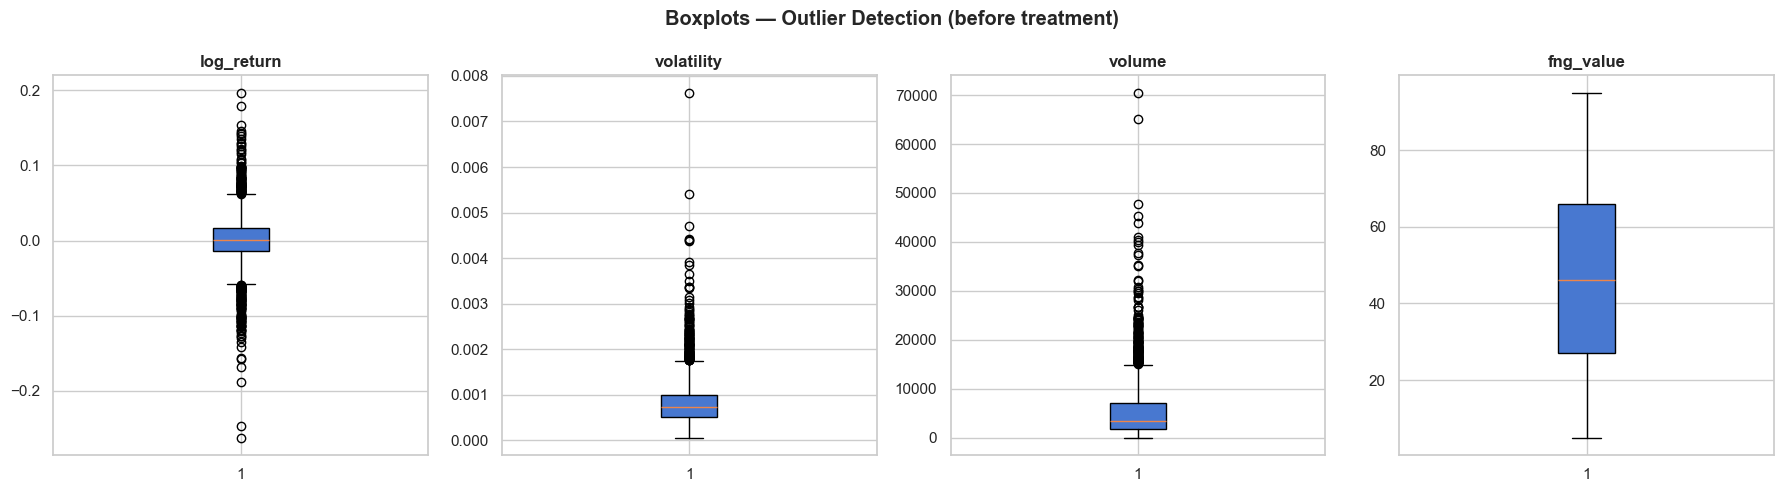

In [16]:
num_cols_plot = ['log_return', 'volatility', 'volume', 'fng_value']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes = axes.flatten() # Converting 2D array of axes into a flat list for easier interpretation

for i, col in enumerate(num_cols_plot):
    axes[i].boxplot(btc_fng[col].dropna(), vert=True, patch_artist=True)
    axes[i].set_title(col, fontweight='bold')

plt.suptitle('Boxplots — Outlier Detection (before treatment)', fontweight='bold')
plt.tight_layout()
plt.show()

Each box shows the interquartile range (Q1–Q3), with the horizontal line inside representing the median. Points plotted beyond the whiskers are considered outliers according to the IQR definition. <br>
The boxplots indicate that:
* `log_return` exhibits both positive and negative outliers, reflecting extreme market movements in both directions, a well-known characteristic of financial return distributions;
* `volatility` presents several upper-tail outliers, corresponding to periods of elevated market uncertainty and intraday instability;
* `volume` is heavily right-skewed with numerous high-value outliers, indicating bursts of trading activity likely associated with major market events;
* `fng_value` shows no significant outliers and remains within a bounded range, as expected for a sentiment index constructed on a fixed scale.

In [17]:
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

print('IQR Outlier Bounds and Counts:')
print(f"{'Column': <14} {'Lower': >10} {'Upper': >10} {'Outliers': >10} {'% of data': >12}") # '<14' means left-align field, 14 chars wide
print(' ' + '-' * 60)

for col in ['log_return', 'volatility', 'volume']:
    lower, upper = iqr_bounds(btc_fng[col])
    n_out = ((btc_fng[col] < lower) | (btc_fng[col] > upper)).sum() # Boolean mask which counts values outside both fences
    print(f' {col: <14} {lower: >10.5f} {upper: >10.5f} {n_out: >10d} {n_out/len(btc_fng)*100: >11.1f}%')

IQR Outlier Bounds and Counts:
Column              Lower      Upper   Outliers    % of data
 ------------------------------------------------------------
 log_return       -0.05848    0.06200        204         8.1%
 volatility       -0.00024    0.00175        127         5.0%
 volume         -6126.59492 14953.89055        159         6.3%


The IQR-based outlier analysis indicates that:

* `log_return` has the highest outlier rate (8.1%), capturing extreme market movements in both positive and negative directions, a well-documented feature of financial return distributions;
* `volume` (6.3%) shows pronounced upper-tail outliers, indicating occasional spikes in trading activity, likely driven by market events or periods of heightened investor interest;
* `volatility` (5.0%) also presents upper-tail outliers, corresponding to periods of elevated market uncertainty and intraday instability.

Notably, `log_return` exhibits both upper and lower outliers due to its symmetric nature around zero, whereas `volume` and `volatility` display primarily upper-tail outliers, consistent with their non-negative and right-skewed distributions. 

-> These patterns suggest that extreme observations are likely genuine market phenomena rather than data errors, and therefore should be retained for analysis.

In [18]:
btc_fng_clean = btc_fng.copy()

for col in ['log_return', 'volatility', 'volume']:
    lower, upper = iqr_bounds(btc_fng[col])
    btc_fng_clean[col] = btc_fng_clean[col].clip(lower=lower, upper=upper)  # The clip function replaces any value that exceeds a bound with the bound value itself

print('Distribution comparison before vs. after Winsorization:\n')
print(f" {'Metric': <28} {'Before': >10} {'After': >10}")
print(' ' + '-' * 52)

stats_to_compare = [
    ('log_return mean', lambda s: s.mean()),
    ('log_return std', lambda s: s.std()),
    ('log_return max', lambda s: s.max()),
    ('volatility mean', lambda s: s.mean()),
    ('volatility max', lambda s: s.max()),
]

targets = {
    'log_return mean': ('log_return', 'log_return'),
    'log_return std': ('log_return', 'log_return'),
    'log_return max': ('log_return', 'log_return'),
    'volatility mean': ('volatility', 'volatility'),
    'volatility max': ('volatility', 'volatility'),
}

for stat_name, func in stats_to_compare:
    col = stat_name.split(' ')[0]
    print(f" {stat_name: <28} {func(btc_fng[col]): >10.6f} {func(btc_fng_clean[col]): >10.6f}")

print(f'\n Rows before: {len(btc_fng)} | Rows after: {len(btc_fng_clean)} (no rows dropped)')

Distribution comparison before vs. after Winsorization:

 Metric                           Before      After
 ----------------------------------------------------
 log_return mean                0.000921   0.001341
 log_return std                 0.035239   0.028215
 log_return max                 0.196923   0.061996
 volatility mean                0.000831   0.000798
 volatility max                 0.007632   0.001752

 Rows before: 2529 | Rows after: 2529 (no rows dropped)


The distribution comparison before and after Winsorization indicates that:

* `log_return` shows a slight increase in mean and a reduction in standard deviation. That indicates that extreme negative and positive returns have been capped, reducing dispersion;
* The substantial decrease in the maximum of `log_return` confirms the effective capping of upper-tail outliers;
* `volatility` exhibits a reduction in both mean and maximum values, indicating that periods of extreme intraday instability have been moderated;
* No observations were removed, preserving the full dataset.

These results suggest that extreme values were relatively infrequent but exerted a disproportionate influence on dispersion measures. Winsorization reduces this influence while maintaining the overall structure and informational content of the data.


***

## 7. Exploration Data Analysis (EDA)
> **Why EDA?** - EDA serves two purposes here: <br>
> 1. *Understand the data* - distributions, central tendencies, temporal patterns, and group-level differences;
> 2. *Inform test selection* - specifically, whether the target variables follow a normal distribution, which determines whether parametric or non-parametric hypothesis tests are appropriate. 

EDA is presented before hypothesis testing, not after, so that test selection is evidence-based rather than post-hoc rationalized.

### 7.1. Distribution of Key Variables

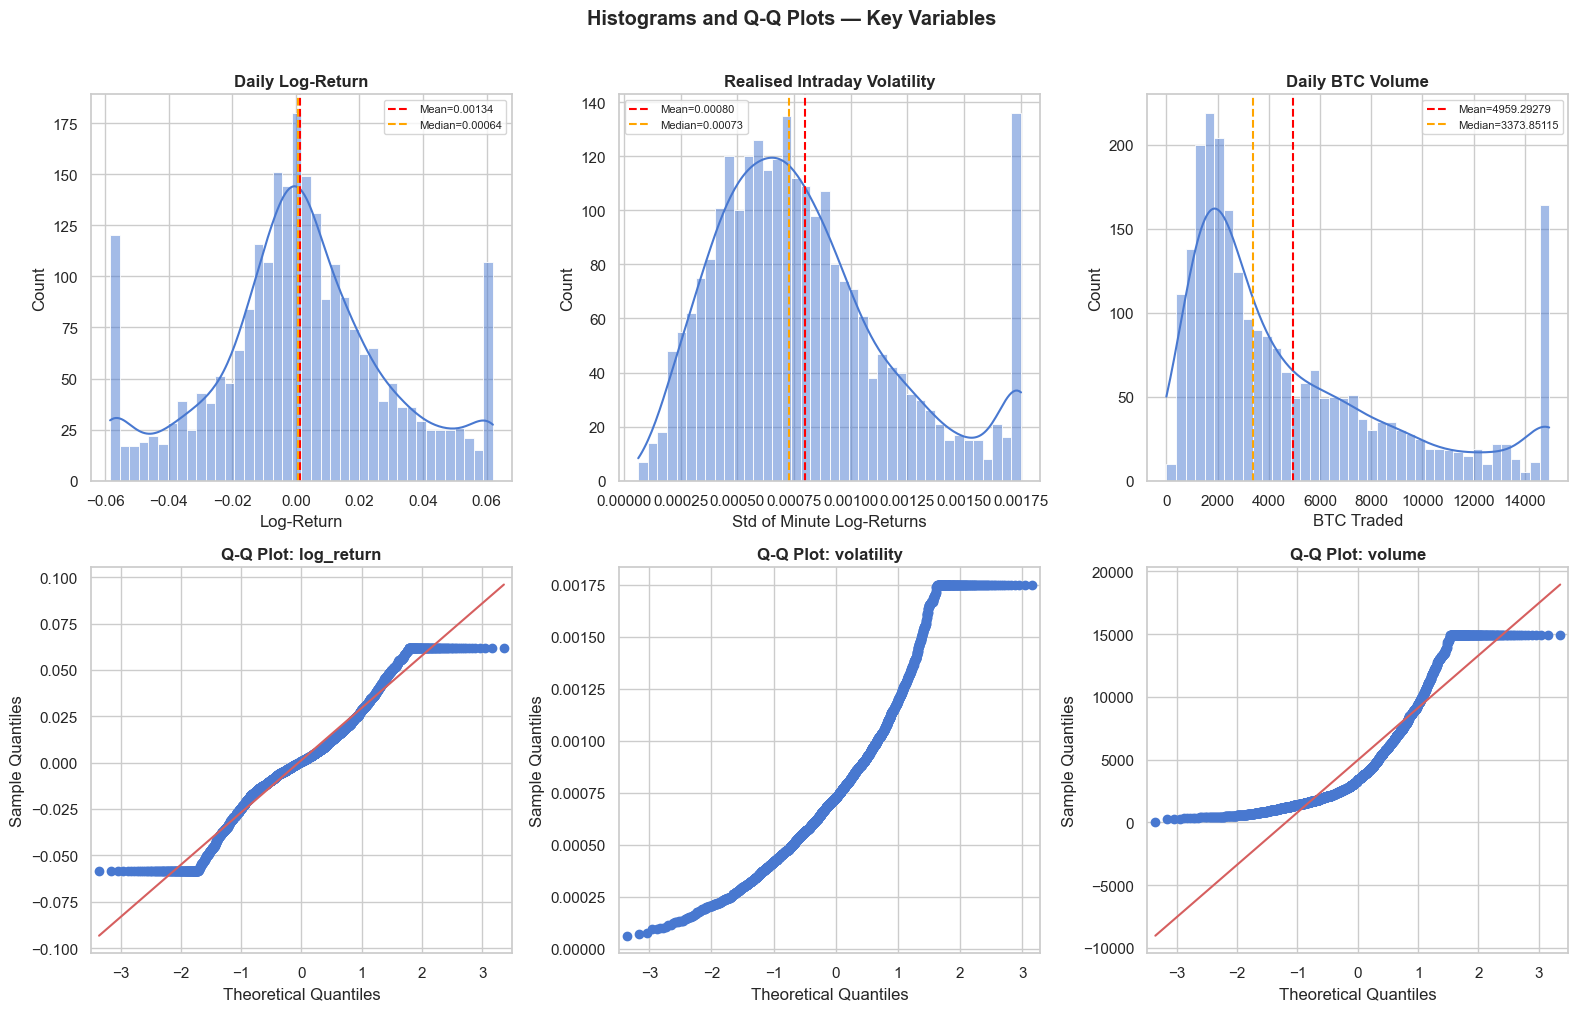

Shapiro-Wilk Normality Tests (n = min(500, N) subsample):
Variable          Statistic        p-value    Normal?
 ------------------------------------------------------
 log_return           0.9706     1.7993e-08         No
 volatility           0.9450     1.1719e-12         No
 volume               0.8432     7.7237e-22         No


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Variables to analyse: (column, plot title, x-axis label)
vars_info = [
    ('log_return', 'Daily Log-Return', 'Log-Return'),
    ('volatility', 'Realised Intraday Volatility', 'Std of Minute Log-Returns'),
    ('volume', 'Daily BTC Volume', 'BTC Traded'),
]

for col_idx, (col, title, xlabel) in enumerate(vars_info):
    ax_hist = axes[0, col_idx]
    ax_qq = axes[1, col_idx]

    # Histogram with KDE + mean / median reference lines
    sns.histplot(btc_fng_clean[col], bins=40, kde=True, ax=ax_hist)
    ax_hist.axvline(btc_fng_clean[col].mean(), color='red', linestyle='--',
                    label=f'Mean={btc_fng_clean[col].mean():.5f}')
    ax_hist.axvline(btc_fng_clean[col].median(), color='orange', linestyle='--',
                    label=f'Median={btc_fng_clean[col].median():.5f}')
    ax_hist.set_title(title, fontweight='bold')
    ax_hist.set_xlabel(xlabel)
    ax_hist.legend(fontsize=8)

    # Q-Q plot to assess normality (deviation from straight line = non-normal)
    qqplot(btc_fng_clean[col], line='s', ax=ax_qq)
    ax_qq.set_title(f'Q-Q Plot: {col}', fontweight='bold')

plt.suptitle('Histograms and Q-Q Plots — Key Variables', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Shapiro–Wilk normality test (subsample to avoid oversensitivity in large N)
print('Shapiro-Wilk Normality Tests (n = min(500, N) subsample):')
print(f"{'Variable': <14} {'Statistic': >12} {'p-value': >14} {'Normal?': >10}")
print(' ' + '-' * 54)

for col, title, _ in vars_info:
    stat, p = shapiro(
        btc_fng_clean[col]
        .dropna()
        .sample(min(500, len(btc_fng_clean)), random_state=42))
    
    normal = 'Yes' if p >= ALPHA else 'No'
    print(f' {col: <14} {stat: >12.4f} {p: >14.4e} {normal: >10}')

* **Log-return:** The distribution is centred around zero, but the Q-Q plot reveals pronounced heavy tails relative to the normal distribution - excess kurtosis is a well-known characteristic of crypto returns;
* **Volatility:** Strongly right-skewed. Most days exhibit low-to-moderate volatility, with occasional spikes corresponding to periods of heightened market uncertainty;
* **Volume:** Also right-skewed - the majority of observations cluster at moderate levels, with infrequent but substantial spikes during major market events;
* **Shapiro-Wilk:** The test rejects normality for all three variables (p < 0.05), confirming that the data deviate from Gaussian assumptions. Consequently, non-parametric methods will be used throughout the hypothesis testing.

### 7.2 Sentiment Category Distribution

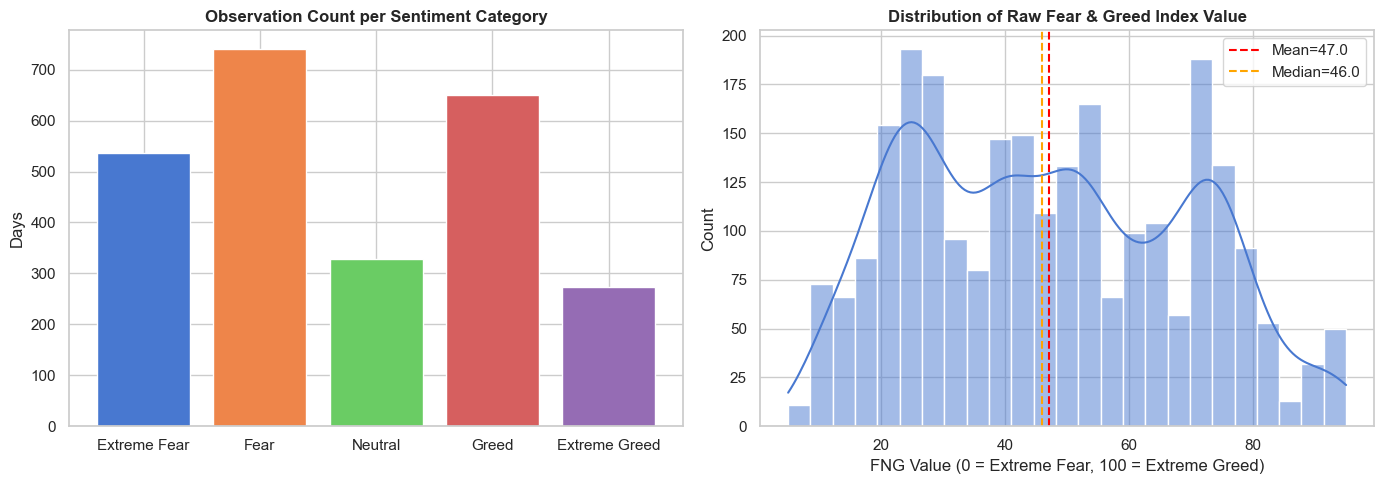

Sentiment category counts and proportions:
  Extreme Fear   :  536 days (21.2%)
  Fear           :  740 days (29.3%)
  Neutral        :  329 days (13.0%)
  Greed          :  651 days (25.7%)
  Extreme Greed  :  273 days (10.8%)


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: number of days per sentiment category (ordered scale)
counts = btc_fng_clean['sentiment'].value_counts().reindex(sentiment_order)
axes[0].bar(sentiment_order, counts.values, color=sns.color_palette('muted', 5))
axes[0].set_title('Observation Count per Sentiment Category', fontweight='bold')
axes[0].set_ylabel('Days')
axes[0].tick_params(axis='x')

# Histogram of raw FNG index with mean / median for central tendency
sns.histplot(btc_fng_clean['fng_value'], bins=25, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Raw Fear & Greed Index Value', fontweight='bold')
axes[1].set_xlabel('FNG Value (0 = Extreme Fear, 100 = Extreme Greed)')

axes[1].axvline(btc_fng_clean['fng_value'].mean(), color='red', linestyle='--',
                label=f'Mean={btc_fng_clean["fng_value"].mean():.1f}')
axes[1].axvline(btc_fng_clean['fng_value'].median(), color='orange', linestyle='--',
                label=f'Median={btc_fng_clean["fng_value"].median():.1f}')

axes[1].legend()

plt.tight_layout()
plt.show()

# Print counts and proportions for each sentiment category
print('Sentiment category counts and proportions:')
for cat in sentiment_order:
    n = (btc_fng_clean['sentiment'] == cat).sum()
    pct = n / len(btc_fng_clean) * 100
    print(f'  {cat: <15}: {n:>4} days ({pct:.1f}%)')

The Sentiment Category Distribution analysis reveals the following patterns:

* **Category counts:** The dataset is dominated by *Fear* (29.3%) and *Greed* (25.7%), followed by *Extreme Fear* (21.2%), while *Neutral* (13.0%) and *Extreme Greed* (10.8%) are less frequent. This indicates that the market spends most of its time in moderately emotional states rather than extreme conditions;
  
* **Imbalance across categories:** The relatively small size of the *Neutral* and *Extreme Greed* groups is important for subsequent statistical testing, as smaller sample sizes reduce statistical power and may affect the reliability of pairwise comparisons;

* **Distribution of FNG values:** The histogram of the raw index shows a broad spread across the full 0-100 range, with mean and median closely aligned, suggesting no strong skewness in the central tendency, although multiple local peaks indicate regime shifts between fear and greed periods;
  
* **Interpretation:** Overall, the sentiment distribution reflects cyclical market behaviour, where periods of fear and greed alternate, rather than a persistent dominance of extreme sentiment states.